# MDSSP Algorithm Comparison - Visualization

This notebook loads pre-computed experiment results and creates visualizations.

**First, run the experiments:**
```bash
python run_experiments.py --runs 30
```

In [66]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Results

In [67]:
# Load results
results_dir = Path('all60')

with open(results_dir / 'all_results.json', 'r') as f:
    results_data = json.load(f)

with open(results_dir / 'best_results.json', 'r') as f:
    best_results = json.load(f)

with open(results_dir / 'summary_statistics.json', 'r') as f:
    summary_stats = json.load(f)

with open(results_dir / 'experiment_config.json', 'r') as f:
    config = json.load(f)

# Create DataFrame
df = pd.DataFrame(results_data)

# Rename algorithms for better display
algorithm_names = {
    'Genetic': 'GA (Greedy Init)',
    'Genetic_Greedy_Init': 'GA (Greedy Init)',
    'Genetic_Stochastic_Init': 'GA (Stochastic Init)',
    'Greedy': 'Greedy',
    'Stochastic_Greedy': 'Stochastic Greedy',
    'CPLEX': 'CPLEX'
}
df['algorithm'] = df['algorithm'].map(lambda x: algorithm_names.get(x, x))

# Also update the keys in summary_stats and best_results for consistency
summary_stats = {algorithm_names.get(k, k): v for k, v in summary_stats.items()}
best_results = {algorithm_names.get(k, k): v for k, v in best_results.items()}

print("✓ Data loaded successfully!")
print(f"\nConfiguration:")
print(f"  Tiles: {config['tiles']}")
print(f"  Tile size: {config['n']} × {config['m']}")
print(f"  Number of runs: {config['runs']}")
print(f"  Total experiments: {len(df)}")
print(f"\nAlgorithms: {', '.join(sorted(df['algorithm'].unique()))}")


✓ Data loaded successfully!

Configuration:
  Tiles: 60
  Tile size: 3 × 3
  Number of runs: 10
  Total experiments: 30

Algorithms: GA (Greedy Init), GA (Stochastic Init), Greedy


## 2. Summary Statistics

In [68]:
print("="*80)
print("AVERAGE STATISTICS OVER ALL RUNS")
print("="*80)

for algo, stats in summary_stats.items():
    print(f"\n{algo}:")
    print(f"  Number of runs: {stats['num_runs']}")
    print(f"  Average Objective: {stats['objective']['mean']:.2f} ± {stats['objective']['std']:.2f}")
    print(f"  Min Objective: {stats['objective']['min']}")
    print(f"  Max Objective: {stats['objective']['max']}")
    print(f"  Average BBox Width: {stats['bbox_width']['mean']:.2f} ± {stats['bbox_width']['std']:.2f}")
    print(f"  Average BBox Height: {stats['bbox_height']['mean']:.2f} ± {stats['bbox_height']['std']:.2f}")
    print(f"  Average Runtime: {stats['runtime']['mean']:.4f}s ± {stats['runtime']['std']:.4f}s")
    print(f"  Min Runtime: {stats['runtime']['min']:.4f}s")
    print(f"  Max Runtime: {stats['runtime']['max']:.4f}s")

print("\n" + "="*80)
print("BEST RESULTS")
print("="*80)
for algo, result in best_results.items():
    print(f"\n{algo}:")
    print(f"  Objective: {result['objective']}")
    print(f"  Bounding Box: {result['bbox_width']} × {result['bbox_height']}")
    print(f"  Runtime: {result['runtime']:.3f}s")
    print(f"  From run {result['run']} (seed={result['seed']})")

AVERAGE STATISTICS OVER ALL RUNS

Greedy:
  Number of runs: 10
  Average Objective: 15.70 ± 0.46
  Min Objective: 15
  Max Objective: 16
  Average BBox Width: 15.50 ± 0.50
  Average BBox Height: 15.60 ± 0.66
  Average Runtime: 1.9770s ± 0.2228s
  Min Runtime: 1.5327s
  Max Runtime: 2.2226s

GA (Stochastic Init):
  Number of runs: 10
  Average Objective: 15.50 ± 0.50
  Min Objective: 15
  Max Objective: 16
  Average BBox Width: 15.50 ± 0.50
  Average BBox Height: 15.40 ± 0.49
  Average Runtime: 30.3530s ± 13.7506s
  Min Runtime: 11.5851s
  Max Runtime: 52.2607s

GA (Greedy Init):
  Number of runs: 10
  Average Objective: 15.20 ± 0.40
  Min Objective: 15
  Max Objective: 16
  Average BBox Width: 15.10 ± 0.54
  Average BBox Height: 15.20 ± 0.40
  Average Runtime: 22.9717s ± 14.3545s
  Min Runtime: 8.9045s
  Max Runtime: 49.8065s

BEST RESULTS

Greedy:
  Objective: 15
  Bounding Box: 15 × 15
  Runtime: 2.214s
  From run 3 (seed=242)

GA (Greedy Init):
  Objective: 15
  Bounding Box: 15 × 1

## 3. Statistical Visualizations

Available algorithms in data: ['GA (Greedy Init)', 'GA (Stochastic Init)', 'Greedy']
Requested algorithm order: ['GA (Greedy Init)', 'GA (Stochastic Init)', 'Stochastic Greedy', 'Greedy']
Final algorithm order (filtered): ['GA (Greedy Init)', 'GA (Stochastic Init)', 'Greedy']



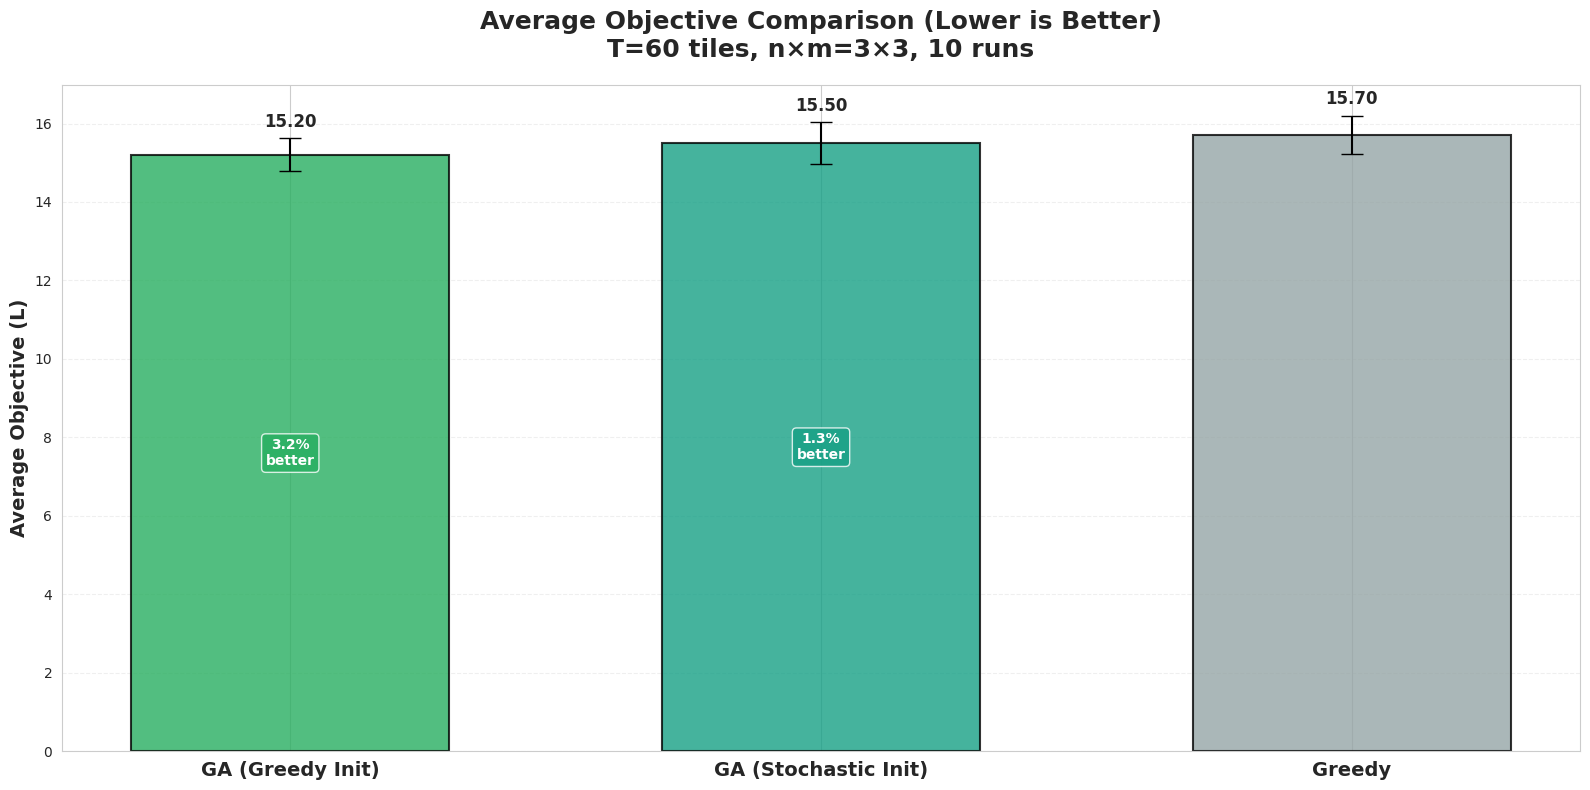

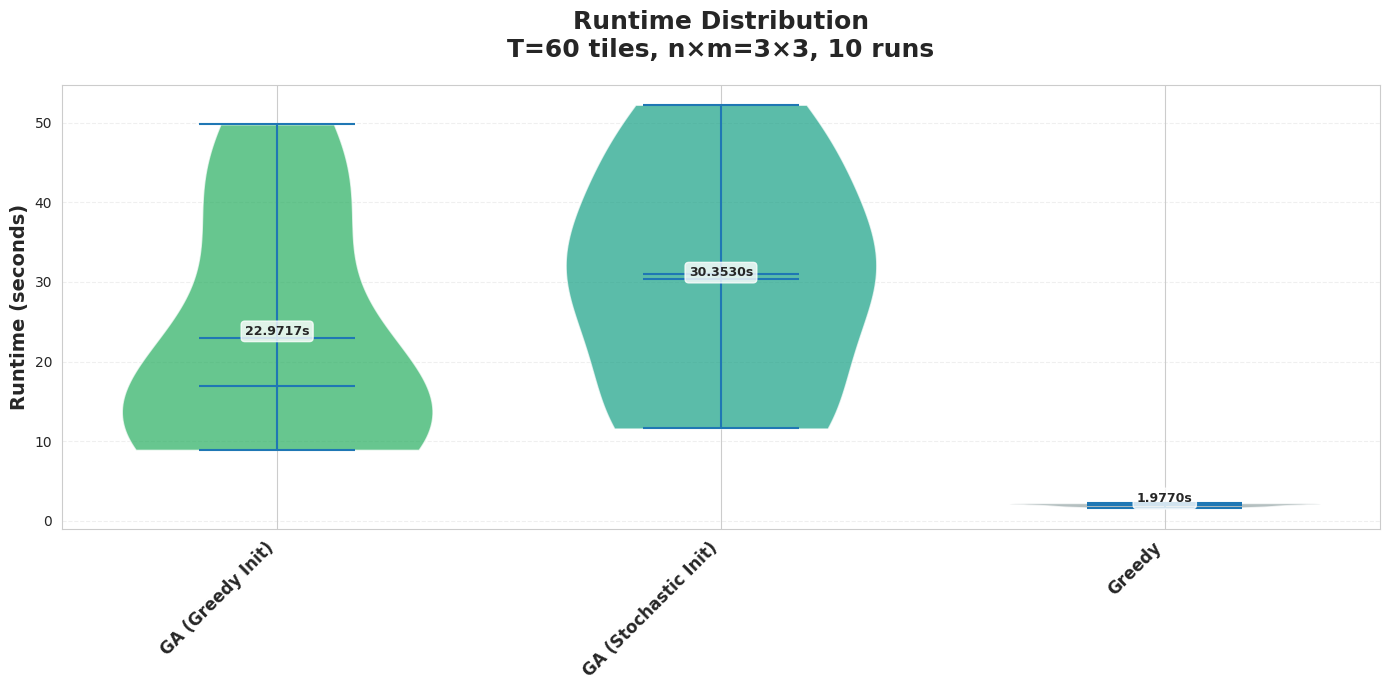

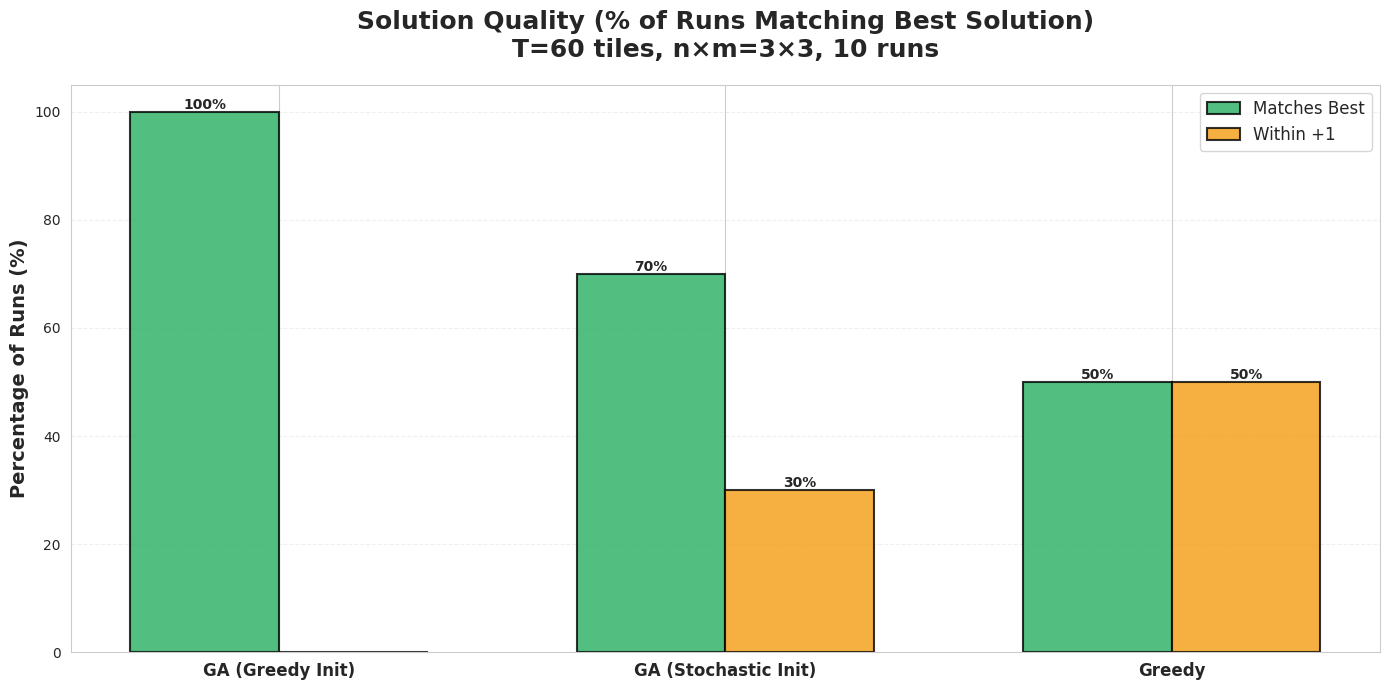

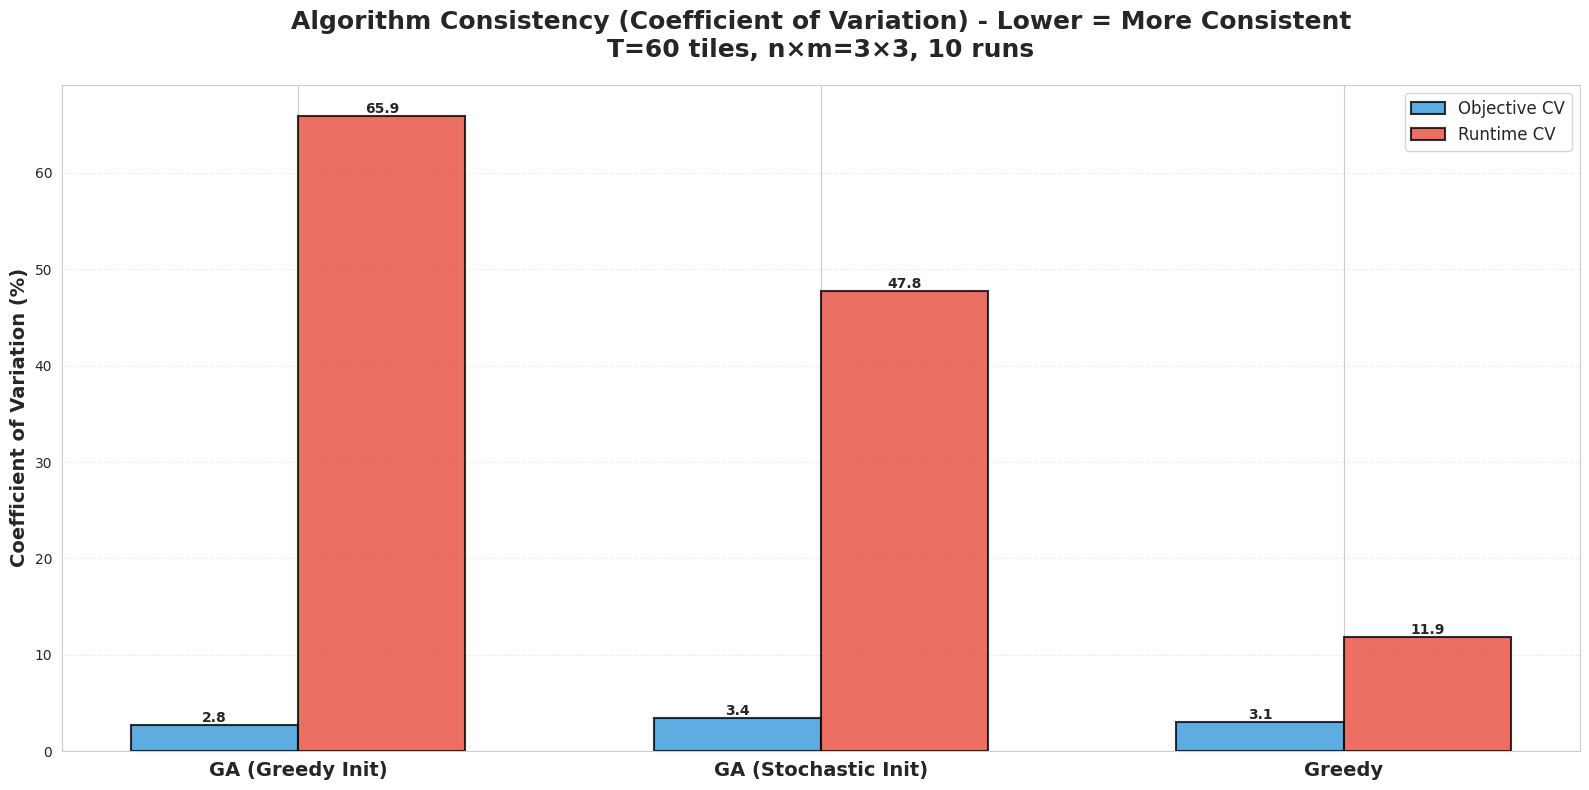

In [69]:
# Define algorithm order for consistent display
algo_order = ['GA (Greedy Init)', 'GA (Stochastic Init)', 
              'Stochastic Greedy', 'Greedy']

# Debug: Check what algorithms are actually in the data
print("Available algorithms in data:", sorted(df['algorithm'].unique()))
print("Requested algorithm order:", algo_order)

# Filter to only include algorithms present in the data
algo_order = [a for a in algo_order if a in df['algorithm'].unique()]
print("Final algorithm order (filtered):", algo_order)
print()

# Define colors for each algorithm type
algo_colors = {
    'CPLEX': '#e74c3c',
    'GA (Greedy Init)': '#27ae60',
    'GA (Stochastic Init)': '#16a085',
    'Stochastic Greedy': '#f39c12',
    'Greedy': '#95a5a6'
}

# ============================================================================
# PLOT 1: Average Objective Comparison
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(16, 8))

avg_objectives = df.groupby('algorithm')['objective'].mean().reindex(algo_order)
std_objectives = df.groupby('algorithm')['objective'].std().reindex(algo_order)
colors = [algo_colors.get(algo, '#95a5a6') for algo in avg_objectives.index]

x_pos = np.arange(len(avg_objectives)) * 2  # Double spacing
bars = ax1.bar(x_pos, avg_objectives.values, yerr=std_objectives.values,
               color=colors, alpha=0.8, capsize=8, width=1.2, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(avg_objectives.index, rotation=0, ha='center', fontsize=14, fontweight='bold')
ax1.set_title(f'Average Objective Comparison (Lower is Better)\nT={config["tiles"]} tiles, n×m={config["n"]}×{config["m"]}, {config["runs"]} runs', 
             fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel('Average Objective (L)', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.set_axisbelow(True)

# Add value labels on top of bars
for i, (algo, val) in enumerate(avg_objectives.items()):
    ax1.text(x_pos[i], val + std_objectives[algo] + 0.2, f'{val:.2f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# Add improvement percentages compared to worst
worst_val = avg_objectives.max()
for i, (algo, val) in enumerate(avg_objectives.items()):
    improvement = (worst_val - val) / worst_val * 100
    if improvement > 0:
        ax1.text(x_pos[i], val * 0.5, f'{improvement:.1f}%\nbetter', 
                ha='center', va='center', fontsize=10, fontweight='bold', 
                color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Runtime Distribution
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(14, 7))

df_ordered = df.copy()
df_ordered['algorithm'] = pd.Categorical(df_ordered['algorithm'], categories=algo_order, ordered=True)
df_ordered = df_ordered.sort_values('algorithm')

parts = ax2.violinplot([df_ordered[df_ordered['algorithm'] == algo]['runtime'].values 
                        for algo in algo_order],
                       positions=range(len(algo_order)), widths=0.7, 
                       showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(algo_colors.get(algo_order[i], '#95a5a6'))
    pc.set_alpha(0.7)

ax2.set_xticks(range(len(algo_order)))
ax2.set_xticklabels(algo_order, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax2.set_title(f'Runtime Distribution\nT={config["tiles"]} tiles, n×m={config["n"]}×{config["m"]}, {config["runs"]} runs', 
             fontsize=18, fontweight='bold', pad=20)
ax2.set_ylabel('Runtime (seconds)', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.set_axisbelow(True)

# Add mean runtime labels
for i, algo in enumerate(algo_order):
    mean_runtime = df_ordered[df_ordered['algorithm'] == algo]['runtime'].mean()
    ax2.text(i, mean_runtime, f'{mean_runtime:.4f}s', 
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 3: Solution Quality (Success Rate)
# ============================================================================
fig3, ax3 = plt.subplots(figsize=(14, 7))

success_data = []
for algo in algo_order:
    algo_data = df[df['algorithm'] == algo]
    optimal_count = 0
    near_optimal_count = 0
    
    for run_num in algo_data['run'].unique():
        run_data = df[df['run'] == run_num]
        best_in_run = run_data['objective'].min()
        algo_obj = algo_data[algo_data['run'] == run_num]['objective'].values[0]
        
        if algo_obj == best_in_run:
            optimal_count += 1
        elif algo_obj <= best_in_run + 1:
            near_optimal_count += 1
    
    total = len(algo_data)
    success_data.append({
        'algorithm': algo,
        'optimal': optimal_count / total * 100,
        'near_optimal': near_optimal_count / total * 100
    })

success_df = pd.DataFrame(success_data).set_index('algorithm').reindex(algo_order)
x_pos = np.arange(len(success_df)) * 1.5
width = 0.5

bars1 = ax3.bar(x_pos - width/2, success_df['optimal'], width, 
               label='Matches Best', color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax3.bar(x_pos + width/2, success_df['near_optimal'], width,
               label='Within +1', color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(success_df.index, rotation=0, ha='center', fontsize=12, fontweight='bold')
ax3.set_title(f'Solution Quality (% of Runs Matching Best Solution)\nT={config["tiles"]} tiles, n×m={config["n"]}×{config["m"]}, {config["runs"]} runs', 
             fontsize=18, fontweight='bold', pad=20)
ax3.set_ylabel('Percentage of Runs (%)', fontweight='bold', fontsize=14)
ax3.legend(loc='best', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')
ax3.set_axisbelow(True)

# Add percentage labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 4: Algorithm Consistency (Coefficient of Variation)
# ============================================================================
fig4, ax4 = plt.subplots(figsize=(16, 8))

cv_data = []
for algo in algo_order:
    algo_data = df[df['algorithm'] == algo]
    cv_obj = algo_data['objective'].std() / algo_data['objective'].mean() * 100
    cv_runtime = algo_data['runtime'].std() / algo_data['runtime'].mean() * 100
    cv_data.append({
        'Algorithm': algo,
        'Objective CV (%)': cv_obj,
        'Runtime CV (%)': cv_runtime
    })

cv_df = pd.DataFrame(cv_data).set_index('Algorithm').reindex(algo_order)
x_pos = np.arange(len(cv_df)) * 2.5
width = 0.8

bars1 = ax4.bar(x_pos - width/2, cv_df['Objective CV (%)'], width,
               label='Objective CV', color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax4.bar(x_pos + width/2, cv_df['Runtime CV (%)'], width,
               label='Runtime CV', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(cv_df.index, rotation=0, ha='center', fontsize=14, fontweight='bold')
ax4.set_title(f'Algorithm Consistency (Coefficient of Variation) - Lower = More Consistent\nT={config["tiles"]} tiles, n×m={config["n"]}×{config["m"]}, {config["runs"]} runs', 
             fontsize=18, fontweight='bold', pad=20)
ax4.set_ylabel('Coefficient of Variation (%)', fontweight='bold', fontsize=14)
ax4.legend(loc='best', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
ax4.set_axisbelow(True)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



## 4. Bounding Box Analysis

/tmp/ipykernel_3589257/1147210486.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ordered, x='algorithm', y='bbox_area', ax=axes[1],


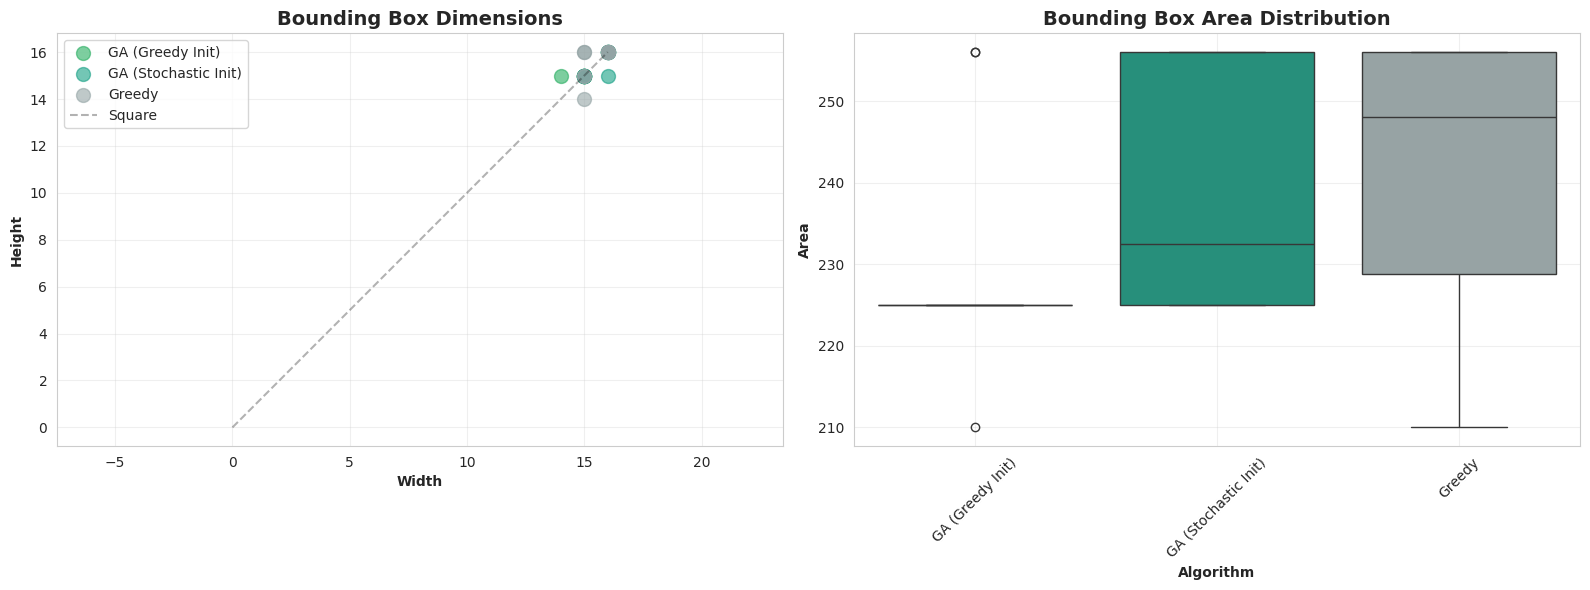

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define algorithm order and colors
algo_order = ['CPLEX', 'GA (Greedy Init)', 'GA (Stochastic Init)', 
              'Stochastic Greedy', 'Greedy']
algo_order = [a for a in algo_order if a in df['algorithm'].unique()]

algo_colors = {
    'CPLEX': '#e74c3c',
    'GA (Greedy Init)': '#27ae60',
    'GA (Stochastic Init)': '#16a085',
    'Stochastic Greedy': '#f39c12',
    'Greedy': '#95a5a6'
}

# Width vs Height
for algo in algo_order:
    algo_data = df[df['algorithm'] == algo]
    axes[0].scatter(algo_data['bbox_width'], algo_data['bbox_height'], 
                   label=algo, s=100, alpha=0.6, color=algo_colors.get(algo, '#95a5a6'))
axes[0].plot([0, df['bbox_width'].max()], [0, df['bbox_height'].max()], 
            'k--', alpha=0.3, label='Square')
axes[0].set_title('Bounding Box Dimensions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Width', fontweight='bold')
axes[0].set_ylabel('Height', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Area distribution
df['bbox_area'] = df['bbox_width'] * df['bbox_height']
df_ordered = df.copy()
df_ordered['algorithm'] = pd.Categorical(df_ordered['algorithm'], categories=algo_order, ordered=True)
df_ordered = df_ordered.sort_values('algorithm')

sns.boxplot(data=df_ordered, x='algorithm', y='bbox_area', ax=axes[1],
            palette=[algo_colors.get(a, '#95a5a6') for a in algo_order])
axes[1].set_title('Bounding Box Area Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Algorithm', fontweight='bold')
axes[1].set_ylabel('Area', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Statistical Tests

In [71]:
from scipy import stats

print("\n" + "="*80)
print("STATISTICAL TESTS (Pairwise Comparisons)")
print("="*80)

# Define algorithm order for better readability
algo_order = ['CPLEX', 'GA (Greedy Init)', 'GA (Stochastic Init)', 
              'Stochastic Greedy', 'Greedy']
algorithms = [a for a in algo_order if a in df['algorithm'].unique()]

# Compare GA variants specifically
print("\n" + "-"*80)
print("GA VARIANTS COMPARISON")
print("-"*80)
ga_variants = ['GA (Greedy Init)', 'GA (Stochastic Init)']
ga_variants = [a for a in ga_variants if a in algorithms]

for i, algo1 in enumerate(ga_variants):
    for algo2 in ga_variants[i+1:]:
        data1 = df[df['algorithm'] == algo1]['objective']
        data2 = df[df['algorithm'] == algo2]['objective']
        
        # Wilcoxon rank-sum test (Mann-Whitney U)
        statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        print(f"\n{algo1} vs {algo2}:")
        print(f"  Mean: {data1.mean():.3f} vs {data2.mean():.3f} (diff: {data1.mean() - data2.mean():.3f})")
        print(f"  Std:  {data1.std():.3f} vs {data2.std():.3f}")
        print(f"  Mann-Whitney U test: statistic={statistic:.2f}, p-value={p_value:.4f}")
        
        if p_value < 0.05:
            if data1.mean() < data2.mean():
                print(f"  ✓ {algo1} is significantly better (p < 0.05)")
            else:
                print(f"  ✓ {algo2} is significantly better (p < 0.05)")
        else:
            print(f"  No significant difference (p >= 0.05)")

print("\n" + "-"*80)
print("ALL ALGORITHMS COMPARISON")
print("-"*80)
for i, algo1 in enumerate(algorithms):
    for algo2 in algorithms[i+1:]:
        data1 = df[df['algorithm'] == algo1]['objective']
        data2 = df[df['algorithm'] == algo2]['objective']
        
        # Wilcoxon rank-sum test (Mann-Whitney U)
        statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        print(f"\n{algo1} vs {algo2}:")
        print(f"  Mean difference: {data1.mean() - data2.mean():.3f}")
        print(f"  Mann-Whitney U test: statistic={statistic:.2f}, p-value={p_value:.4f}")
        
        if p_value < 0.05:
            if data1.mean() < data2.mean():
                print(f"  ✓ {algo1} is significantly better (p < 0.05)")
            else:
                print(f"  ✓ {algo2} is significantly better (p < 0.05)")
        else:
            print(f"  No significant difference (p >= 0.05)")



STATISTICAL TESTS (Pairwise Comparisons)

--------------------------------------------------------------------------------
GA VARIANTS COMPARISON
--------------------------------------------------------------------------------

GA (Greedy Init) vs GA (Stochastic Init):
  Mean: 15.200 vs 15.500 (diff: -0.300)
  Std:  0.422 vs 0.527
  Mann-Whitney U test: statistic=35.00, p-value=0.1851
  No significant difference (p >= 0.05)

--------------------------------------------------------------------------------
ALL ALGORITHMS COMPARISON
--------------------------------------------------------------------------------

GA (Greedy Init) vs GA (Stochastic Init):
  Mean difference: -0.300
  Mann-Whitney U test: statistic=35.00, p-value=0.1851
  No significant difference (p >= 0.05)

GA (Greedy Init) vs Greedy:
  Mean difference: -0.500
  Mann-Whitney U test: statistic=25.00, p-value=0.0318
  ✓ GA (Greedy Init) is significantly better (p < 0.05)

GA (Stochastic Init) vs Greedy:
  Mean difference: 

## 6. Export Summary

In [72]:
# Save results to CSV
output_file = 'algorithm_comparison_results.csv'
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")

# Save summary to text file
summary_file = 'algorithm_comparison_summary.txt'
with open(summary_file, 'w') as f:
    f.write("MDSSP Algorithm Comparison Summary\n")
    f.write("="*80 + "\n\n")
    f.write(f"Configuration:\n")
    f.write(f"  Tiles: {config['tiles']}\n")
    f.write(f"  Tile size: {config['n']} × {config['m']}\n")
    f.write(f"  Number of runs: {config['runs']}\n\n")
    
    f.write("Average Statistics:\n")
    f.write("-" * 80 + "\n")
    for algo, stats in summary_stats.items():
        f.write(f"\n{algo}:\n")
        f.write(f"  Avg Objective: {stats['objective']['mean']:.2f} ± {stats['objective']['std']:.2f}\n")
        f.write(f"  Avg Runtime: {stats['runtime']['mean']:.4f}s ± {stats['runtime']['std']:.4f}s\n")
    
print(f"Summary saved to {summary_file}")
print("\n✓ Analysis complete!")

Results saved to algorithm_comparison_results.csv
Summary saved to algorithm_comparison_summary.txt

✓ Analysis complete!
